# Poker engine — Monte Carlo equity demo

Imports the package from `src/` (project root is detected automatically so this runs whether the kernel cwd is `notebooks/` or the repo root).

In [5]:
from src.Board import Board
from src.Card import Card
from src.Evaluator import Evaluator
from src.Player import Player
from utils.plotting import plot_equity_convergence

In [2]:
# Specific hand: pocket Queens (Queen of Hearts, Queen of Diamonds)
# Board: Ace of Spades, King of Clubs, Seven of Hearts (Ace-high dry flop)

hero = Player(
    [
        Card(12, 2),  # Qh
        Card(12, 1),  # Qd
    ]
)

board = Board(
    [
        Card(14, 3),  # As
        Card(13, 0),  # Kc
        Card(7, 2),  # 7h
    ]
)

board_cards = [c for c in board.cards() if c is not None]

print("Hero:", hero.to_str())
print("Board:", board.to_str())

Hero: Queen of Hearts, Queen of Diamonds
Board: Ace of Spades, King of Clubs, 7 of Hearts


In [3]:
evaluator = Evaluator()

sim_num = 10_000
opponents = 1  # heads-up

final_equity, equity_tracker = evaluator.hand_equity(
    hero.cards(),
    sim_num,
    opponents,
    board=board_cards,
)

print(f"Final equity (win + tie share): {final_equity:.6f}")
print(f"Convergence series length: {len(equity_tracker)}")

10.0% Complete
20.0% Complete
30.0% Complete
40.0% Complete
50.0% Complete
60.0% Complete
70.0% Complete
80.0% Complete
90.0% Complete
100.0% Complete
Final equity (win + tie share): 0.720650
Convergence series length: 10000


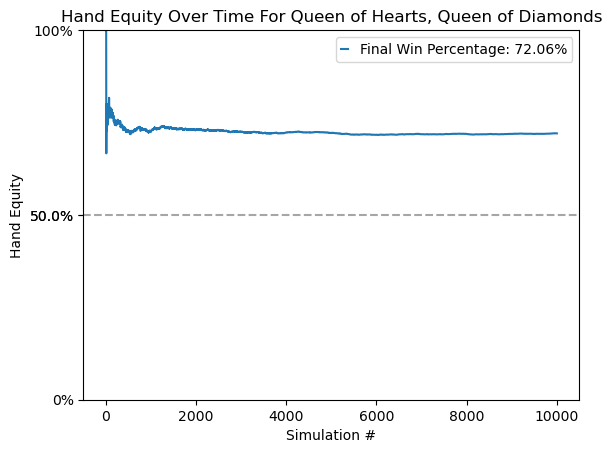

In [9]:
plot_equity_convergence(sim_num, equity_tracker, final_equity, hero.cards(), opponents)